<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/aliya's-LR/dmw_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:

# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score,
    precision_score
)

In [14]:
# ==========================================
# STEP 1: Load and Inspect Data
# ==========================================

from google.colab import drive
import csv # Import csv module for quoting options
# drive.mount('/content/drive')

# Load the dataset
filename = '/content/synthetic_financial_data_NOISY (1).csv'
# Added sep='|', engine='python', quotechar=None, and quoting=csv.QUOTE_NONE to correctly parse pipe-delimited data
df = pd.read_csv(filename, on_bad_lines='skip', sep='|', engine='python', quotechar=None, quoting=csv.QUOTE_NONE)

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")

✅ Data Loaded Successfully!
Shape: (1146, 8)


In [17]:

# ==========================================
# STEP 2: Data Preprocessing
# ==========================================

print("\n" + "="*50)
print("PREPROCESSING DATA")
print("="*50)

# 2.1 Drop columns that are not useful for prediction
# Customer_ID is just an identifier
# Loan_Officer_Note is unstructured text (difficult to process)
df_clean = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

print(f"Columns after dropping ID and Notes: {df_clean.columns.tolist()}")

# 2.2 Check for missing values
print(f"\nMissing values per column:")
print(df_clean.isnull().sum())

# 2.3 Define Features (X) and Target (y)
# Target: 'Default_Status' (0 = Paid, 1 = Default)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

# 2.4 Split Data into Training and Testing Sets
# 80-20 split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set default rate: {y_train.mean():.2%}")
print(f"Test set default rate: {y_test.mean():.2%}")

# 2.5 Feature Scaling
# Logistic Regression is sensitive to feature scales
# Standardize features to have mean=0 and std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data Preprocessing Complete.")


PREPROCESSING DATA
Columns after dropping ID and Notes: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Default_Status']

Missing values per column:
Age                 0
Annual_Income       0
Credit_Score        0
Loan_Amount         0
Loan_Term_Months    0
Default_Status      0
dtype: int64

Features (X) shape: (1146, 5)
Target (y) shape: (1146,)
Feature columns: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months']

Training set size: 916
Test set size: 230
Training set default rate: 38.43%
Test set default rate: 38.70%

✅ Data Preprocessing Complete.


In [18]:

# ==========================================
# STEP 3: Train Logistic Regression Model
# ==========================================

print("\n" + "="*50)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("="*50)

# Initialize the Logistic Regression model
# Parameters explained:
# - max_iter: Maximum number of iterations for convergence
# - random_state: For reproducibility
# - class_weight='balanced': Automatically handles class imbalance
# - solver='lbfgs': Good for small-to-medium datasets
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)

# Check for NaN values in training data
nan_rows = np.isnan(X_train_scaled).any(axis=1)
if nan_rows.any():
    X_train_cleaned = X_train_scaled[~nan_rows]
    y_train_cleaned = y_train.iloc[~nan_rows]
    print(f"⚠️ Warning: Removed {np.sum(nan_rows)} rows containing NaN values from training data.")
else:
    X_train_cleaned = X_train_scaled
    y_train_cleaned = y_train

# Train the model on the scaled training data
lr_model.fit(X_train_cleaned, y_train_cleaned)

print("✅ Model Training Complete.")
print(f"Number of iterations to converge: {lr_model.n_iter_[0]}")


TRAINING LOGISTIC REGRESSION MODEL
✅ Model Training Complete.
Number of iterations to converge: 5


In [21]:

# ==========================================
# STEP 4: Evaluation & Metrics
# ==========================================

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Make predictions on the test set
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability for class 1 (Default)

# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_precision = precision_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

# Calculate feature importance for Logistic Regression
# Coefficients show the log-odds impact of each feature
feature_names = X_train.columns.tolist()
coefficients = lr_model.coef_[0]

# Create DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

# Get top 5 most important features (by absolute value)
top_features = feature_importance_df.head(5)

# Format the top features into a string for the LLM prompt
top_features_str = "\n".join([
    f"- {row['Feature']}: {row['Coefficient']:.4f} (abs: {row['Abs_Coefficient']:.4f})"
    for _, row in top_features.iterrows()
])

# Print detailed performance metrics
print("\n" + "="*50)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy:   {metric_accuracy:.4f} ({metric_accuracy:.2%})")
print(f"Precision:  {metric_precision:.4f} ({metric_precision:.2%}) - How many predicted defaults are actual defaults")
print(f"Recall:     {metric_recall:.4f} ({metric_recall:.2%}) - How many actual defaults we caught")
print(f"F1-Score:   {metric_f1:.4f} (Harmonic mean of Precision & Recall)")
print(f"ROC-AUC:    {metric_auc:.4f} (Area under ROC curve)")

print("\n" + "-"*50)
print("CLASSIFICATION REPORT")
print("-"*50)
print(classification_report(y_test, y_pred, target_names=['Paid (0)', 'Default (1)']))

print("\n" + "-"*50)
print("TOP 5 MOST IMPORTANT FEATURES")
print("-"*50)
print(feature_importance_df.head(5).to_string(index=False))
print("\nNote: Positive coefficient = increases default probability")
print("      Negative coefficient = decreases default probability")



MODEL EVALUATION

LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy:   0.6783 (67.83%)
Precision:  0.5701 (57.01%) - How many predicted defaults are actual defaults
Recall:     0.6854 (68.54%) - How many actual defaults we caught
F1-Score:   0.6224 (Harmonic mean of Precision & Recall)
ROC-AUC:    0.6839 (Area under ROC curve)

--------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

    Paid (0)       0.77      0.67      0.72       141
 Default (1)       0.57      0.69      0.62        89

    accuracy                           0.68       230
   macro avg       0.67      0.68      0.67       230
weighted avg       0.69      0.68      0.68       230


--------------------------------------------------
TOP 5 MOST IMPORTANT FEATURES
--------------------------------------------------
         Feature  Coefficient  Abs_Coefficient
     Loan_Amount    -0.247867         0.2


GENERATING VISUALIZATIONS


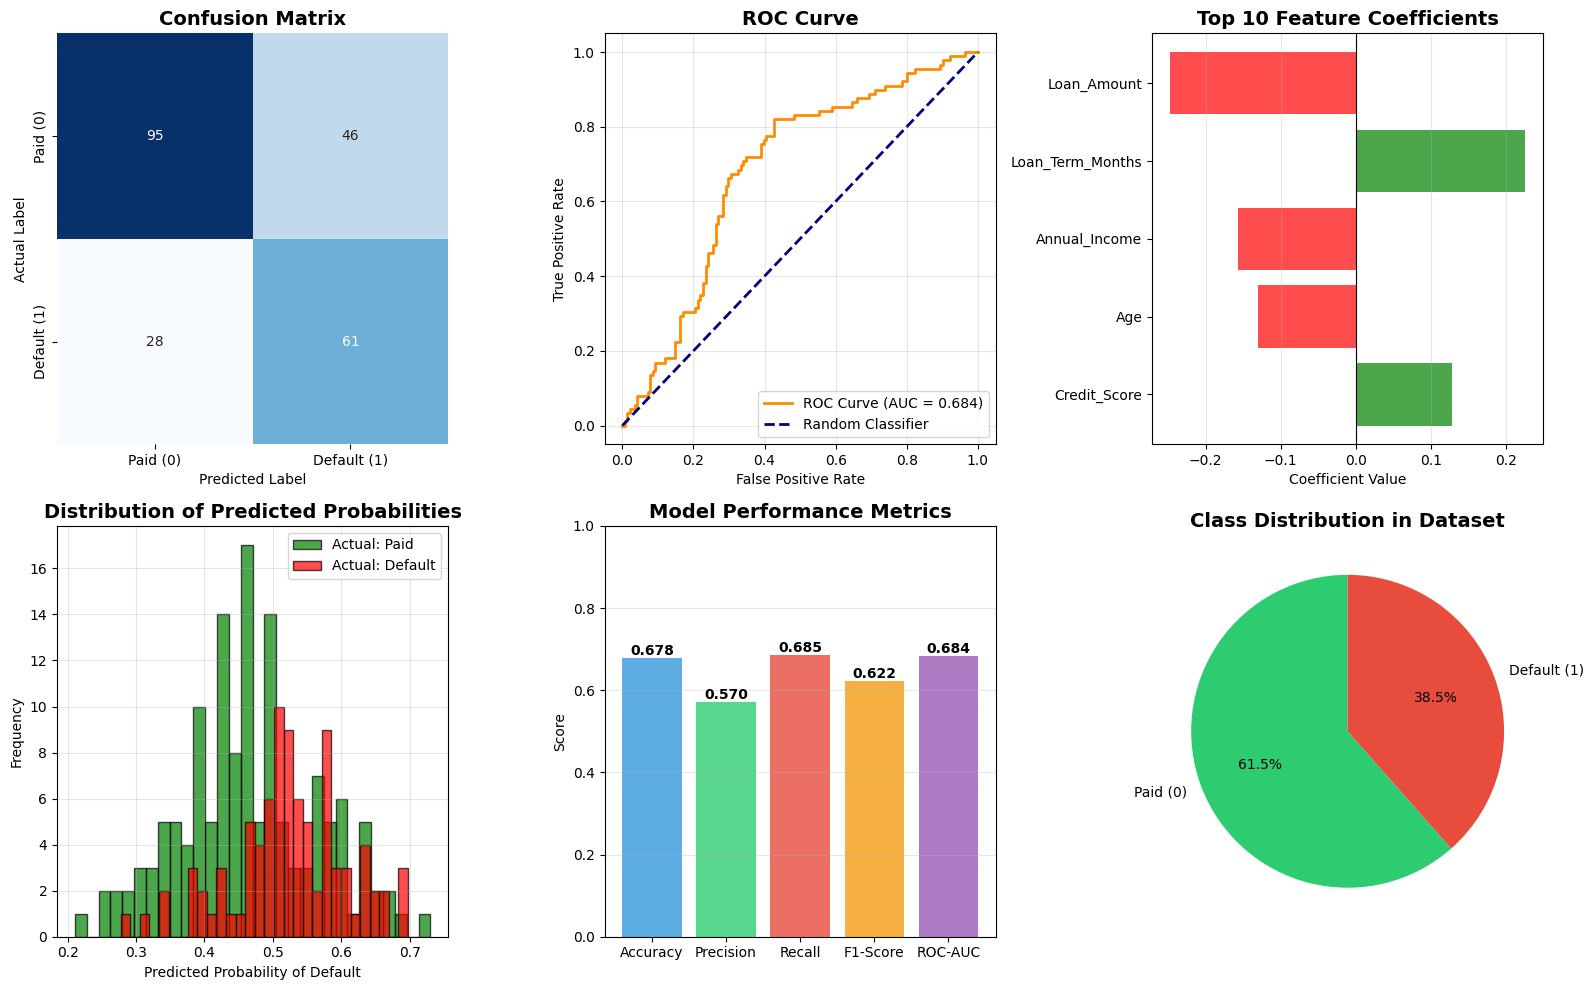

✅ Visualizations Generated.


In [22]:

# ==========================================
# STEP 5: Visualizations
# ==========================================

print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# Create a comprehensive visualization
fig = plt.figure(figsize=(16, 10))

# 5.1 Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('Actual Label')
ax1.set_xticklabels(['Paid (0)', 'Default (1)'])
ax1.set_yticklabels(['Paid (0)', 'Default (1)'])

# 5.2 ROC Curve
ax2 = plt.subplot(2, 3, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {metric_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 5.3 Feature Importance (Top 10)
ax3 = plt.subplot(2, 3, 3)
top_10_features = feature_importance_df.head(10)
colors = ['red' if x < 0 else 'green' for x in top_10_features['Coefficient']]
ax3.barh(range(len(top_10_features)), top_10_features['Coefficient'], color=colors, alpha=0.7)
ax3.set_yticks(range(len(top_10_features)))
ax3.set_yticklabels(top_10_features['Feature'])
ax3.set_xlabel('Coefficient Value')
ax3.set_title('Top 10 Feature Coefficients', fontsize=14, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# 5.4 Prediction Distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(y_prob[y_test == 0], bins=30, alpha=0.7, label='Actual: Paid', color='green', edgecolor='black')
ax4.hist(y_prob[y_test == 1], bins=30, alpha=0.7, label='Actual: Default', color='red', edgecolor='black')
ax4.set_xlabel('Predicted Probability of Default')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5.5 Performance Metrics Bar Chart
ax5 = plt.subplot(2, 3, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [metric_accuracy, metric_precision, metric_recall, metric_f1, metric_auc]
bars = ax5.bar(metrics_names, metrics_values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], alpha=0.8)
ax5.set_ylabel('Score')
ax5.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.3f}',
             ha='center', va='bottom', fontweight='bold')

# 5.6 Class Distribution
ax6 = plt.subplot(2, 3, 6)
class_counts = y.value_counts()
ax6.pie(class_counts.values, labels=['Paid (0)', 'Default (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
ax6.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizations Generated.")

In [ ]:

# ==========================================
# PART B: THE LLM ANALYSIS (The Insight)
# ==========================================

print("\n" + "="*50)
print("PREPARING LLM ANALYSIS")
print("="*50)

# Install bitsandbytes if needed
!pip install -q -U bitsandbytes

print("⏳ Loading LLM for Analysis...")

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

# Setup Model with 4-bit quantization for efficiency
model_name = "microsoft/Phi-3-mini-4k-instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"
)

print("✅ LLM Loaded Successfully!")

# Construct the Prompt with your specific data
analysis_prompt = f"""[INST] You are a Data Science Expert specializing in credit risk analysis.

I have trained a Logistic Regression model to predict Loan Defaults using customer financial data including Age, Annual Income, Credit Score, Loan Amount, and Loan Term.

Please analyze the performance metrics and feature importance listed below.

### MODEL PERFORMANCE:
- Accuracy: {metric_accuracy:.2%} (Overall correct predictions)
- Precision: {metric_precision:.2%} (Of predicted defaults, how many were correct)
- Recall: {metric_recall:.2%} (Of actual defaults, how many did we catch)
- F1-Score: {metric_f1:.4f} (Balance between Precision and Recall)
- ROC-AUC: {metric_auc:.4f} (Model's ability to discriminate between classes)

### TOP 5 MOST IMPORTANT FEATURES (Logistic Regression Coefficients):
{top_features_str}

Note: Positive coefficients increase default probability, negative coefficients decrease it.

### DATASET CONTEXT:
- Total samples: {len(df)}
- Default rate: {y.mean():.2%}
- Features include: Age, Annual Income, Credit Score, Loan Amount, Loan Term (months)

### INSTRUCTIONS:
1. Summarize the model's performance. Is it suitable for real-world credit risk management? Consider the trade-off between catching defaulters (recall) and avoiding false alarms (precision).

2. Interpret the Top 5 Features. Explain why each feature's coefficient (positive or negative) makes business sense in predicting loan defaults.

3. Provide TWO specific business recommendations:
   a) One for improving the model's performance
   b) One for how the bank should use these insights in their loan approval process
[/INST]"""

# Generate the Analysis
print("\n🤖 Generating Analysis from LLM...")
print("This may take 1-2 minutes...\n")

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=1024,
    do_sample=True,
    temperature=0.1,
    repetition_penalty=1.0
)

output = generator(analysis_prompt)
generated_text = output[0]['generated_text']

# Display Result
print("\n" + "="*60)
print("📊 LLM AUTOMATED FINDINGS & INSIGHTS")
print("="*60)
# Extract only the response part (after [/INST])
llm_response = generated_text.split("[/INST]")[-1].strip()
print(llm_response)

print("\n" + "="*60)
print("✅ ANALYSIS COMPLETE!")
print("="*60)


PREPARING LLM ANALYSIS
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 12.4 MB/s eta 0:00:00
⏳ Loading LLM for Analysis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Device set to use cpu


✅ LLM Loaded Successfully!

🤖 Generating Analysis from LLM...
This may take 1-2 minutes...

